# AS7341 Class Visualization

This notebook loads the readings from `as7341_readings.txt`, validates that each sample has **10 features**, normalizes the vectors, and assigns labels to **7 ordered classes**.

Instead of using unconstrained clustering, the notebook now uses **ordered statistical segmentation**: it assumes the file is arranged in class order and finds the best 7 contiguous blocks whose within-class variance is as small as possible.

The class names are assigned in this order: `orange`, `purple`, `blue`, `green`, `yellow`, `pink`, `red`.

A final section also keeps a simple **unknown-candidate heuristic** based on distance to the assigned class centroid. That is not a true unknown-class model yet, but it is a practical starting point for a future AI classifier.

In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

sns.set_theme(style="whitegrid", context="talk")

DATA_PATH = Path("as7341_readings.txt")
FEATURE_NAMES = [f"feature_{index}" for index in range(1, 11)]
RANDOM_STATE = 42
ORDERED_CLASS_NAMES = ["orange", "purple", "blue", "green", "yellow", "pink", "red"]
CLASS_COLOR_MAP = {
    "orange": "#ff8c00",
    "purple": "#7b2cbf",
    "blue": "#1f77b4",
    "green": "#2ca02c",
    "yellow": "#ffe600",
    "pink": "#e75480",
    "red": "#ff0000",
}
UNKNOWN_DISTANCE_PERCENTILE = 95
MIN_CLASS_SIZE = 60
MAX_CLASS_SIZE = 120


def load_vectors(path: Path) -> np.ndarray:
    rows = []
    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip().rstrip(",")
        if not line:
            continue
        rows.append(ast.literal_eval(line))
    return np.asarray(rows, dtype=float)


def compute_segment_cost_tables(X_values: np.ndarray):
    prefix_sum = np.vstack([np.zeros((1, X_values.shape[1])), np.cumsum(X_values, axis=0)])
    prefix_sq = np.concatenate([[0.0], np.cumsum(np.sum(X_values**2, axis=1))])
    return prefix_sum, prefix_sq


def segment_sse(start: int, end: int, prefix_sum: np.ndarray, prefix_sq: np.ndarray) -> float:
    length = end - start
    segment_sum = prefix_sum[end] - prefix_sum[start]
    segment_sq = prefix_sq[end] - prefix_sq[start]
    return float(segment_sq - np.dot(segment_sum, segment_sum) / length)


def infer_ordered_segments(
    X_values: np.ndarray,
    ordered_labels: list[str],
    min_size: int,
    max_size: int,
):
    n_samples = len(X_values)
    n_classes = len(ordered_labels)
    prefix_sum, prefix_sq = compute_segment_cost_tables(X_values)

    dp = np.full((n_classes + 1, n_samples + 1), np.inf)
    prev = np.full((n_classes + 1, n_samples + 1), -1, dtype=int)
    dp[0, 0] = 0.0

    for class_index in range(1, n_classes + 1):
        min_end = class_index * min_size
        max_end = min(n_samples, class_index * max_size)
        for end in range(min_end, max_end + 1):
            start_min = max((class_index - 1) * min_size, end - max_size)
            start_max = min((class_index - 1) * max_size, end - min_size)
            for start in range(start_min, start_max + 1):
                previous_cost = dp[class_index - 1, start]
                if np.isinf(previous_cost):
                    continue
                cost = previous_cost + segment_sse(start, end, prefix_sum, prefix_sq)
                if cost < dp[class_index, end]:
                    dp[class_index, end] = cost
                    prev[class_index, end] = start

    if np.isinf(dp[n_classes, n_samples]):
        raise ValueError("No valid ordered segmentation found. Adjust min/max class sizes.")

    boundaries = [n_samples]
    end = n_samples
    for class_index in range(n_classes, 0, -1):
        start = prev[class_index, end]
        boundaries.append(start)
        end = start
    boundaries = list(reversed(boundaries))

    labels = np.empty(n_samples, dtype=object)
    segment_ranges = []
    for class_index, label in enumerate(ordered_labels):
        start = boundaries[class_index]
        end = boundaries[class_index + 1]
        labels[start:end] = label
        segment_ranges.append((label, start, end, end - start))

    return labels, boundaries, segment_ranges


def ordered_labels_present(labels: np.ndarray) -> list[str]:
    label_set = set(labels.tolist())
    return [label for label in ORDERED_CLASS_NAMES if label in label_set]


def plot_projection(points: np.ndarray, labels: np.ndarray, title: str, xlabel: str, ylabel: str) -> None:
    ordered_labels = ordered_labels_present(labels)

    plt.figure(figsize=(9, 7))
    for label in ordered_labels:
        index = labels == label
        plt.scatter(
            points[index, 0],
            points[index, 1],
            s=60,
            alpha=0.8,
            label=label,
            color=CLASS_COLOR_MAP[label],
            edgecolor="none",
        )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## 1. Load the Sensor Vectors and Statistically Label the 7 Ordered Classes

This section reads the text file, checks that each sample has exactly 10 dimensions, normalizes the vectors, and finds the best **7 contiguous segments** under a minimum-variance criterion.

Those segments are then labeled in the known acquisition order: `orange`, `purple`, `blue`, `green`, `yellow`, `pink`, `red`.

In [2]:
X = load_vectors(DATA_PATH)
assert X.ndim == 2, f"Expected a 2D array, got shape {X.shape}"
assert X.shape[1] == 10, f"Expected 10 features, got {X.shape[1]}"

X_norm = normalize(X, norm="l2")

class_names, segment_boundaries, segment_ranges = infer_ordered_segments(
    X_norm,
    ORDERED_CLASS_NAMES,
    min_size=MIN_CLASS_SIZE,
    max_size=MAX_CLASS_SIZE,
)
class_order = ORDERED_CLASS_NAMES.copy()
class_to_id = {label: index for index, label in enumerate(class_order)}
class_ids = np.array([class_to_id[label] for label in class_names])
class_sizes = {label: int(np.sum(class_names == label)) for label in class_order}
segmentation_silhouette = silhouette_score(X_norm, class_ids)

centroids = np.vstack([
    X_norm[class_names == label].mean(axis=0)
    for label in class_order
])
centroid_distances = np.linalg.norm(X_norm - centroids[class_ids], axis=1)
assigned_distances = centroid_distances
unknown_distance_threshold = np.percentile(assigned_distances, UNKNOWN_DISTANCE_PERCENTILE)
unknown_candidates = assigned_distances >= unknown_distance_threshold

print(f"Loaded {len(X)} samples from {DATA_PATH}.")
print(f"Detected feature count: {X.shape[1]}")
print(f"Using ordered class names: {class_order}")
print(f"Segmentation silhouette score: {segmentation_silhouette:.3f}")
print(
    f"Unknown-candidate threshold: top {100 - UNKNOWN_DISTANCE_PERCENTILE:.0f}% farthest samples from their class centroid"
)
print(f"Unknown-candidate sample count: {int(np.sum(unknown_candidates))}")
print("\nInferred class ranges:")
for label, start, end, size in segment_ranges:
    print(f"  {label:>6}: rows {start}-{end - 1} ({size} samples)")

Loaded 697 samples from as7341_readings.txt.
Detected feature count: 10
Using ordered class names: ['orange', 'purple', 'blue', 'green', 'yellow', 'pink', 'red']
Segmentation silhouette score: 0.891
Unknown-candidate threshold: top 5% farthest samples from their class centroid
Unknown-candidate sample count: 35

Inferred class ranges:
  orange: rows 0-97 (98 samples)
  purple: rows 98-197 (100 samples)
    blue: rows 198-298 (101 samples)
   green: rows 299-397 (99 samples)
  yellow: rows 398-496 (99 samples)
    pink: rows 497-596 (100 samples)
     red: rows 597-696 (100 samples)


## 2. Inspect the Ordered Statistical Labeling

The first plot shows the inferred sample count for each named class after ordered segmentation.

The second plot shows where the class boundaries fall in the original file order, so you can verify that the statistical split matches the acquisition sequence.

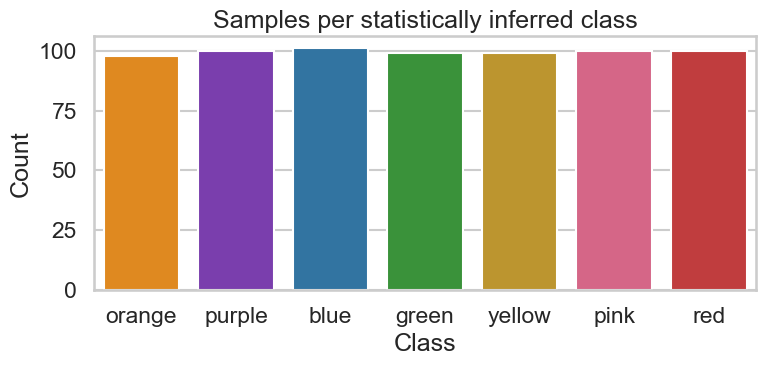

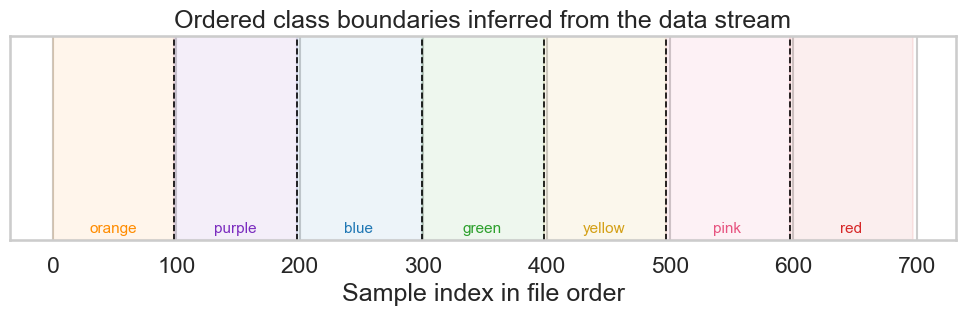

In [30]:
plt.figure(figsize=(8, 4))
sns.countplot(x=class_names, hue=class_names, order=class_order, palette=CLASS_COLOR_MAP, legend=False)
plt.title("Samples per statistically inferred class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

boundary_positions = np.array(segment_boundaries[1:-1])
plt.figure(figsize=(10, 3.5))
for label, start, end, _ in segment_ranges:
    plt.axvspan(start, end, color=CLASS_COLOR_MAP[label], alpha=0.08)
for boundary in boundary_positions:
    plt.axvline(boundary, color="black", linestyle="--", linewidth=1.2)
for label, start, end, _ in segment_ranges:
    midpoint = (start + end - 1) / 2
    plt.text(midpoint, 0.02, label, ha="center", va="bottom", fontsize=11, color=CLASS_COLOR_MAP[label])
plt.yticks([])
plt.xlabel("Sample index in file order")
plt.title("Ordered class boundaries inferred from the data stream")
plt.tight_layout()
plt.show()

## 3. Project the 10-D Vectors into 2D

PCA gives a global linear view of the data, while t-SNE emphasizes local neighborhood structure. Both plots are colored by the **ordered statistical labels** rather than unconstrained clustering.

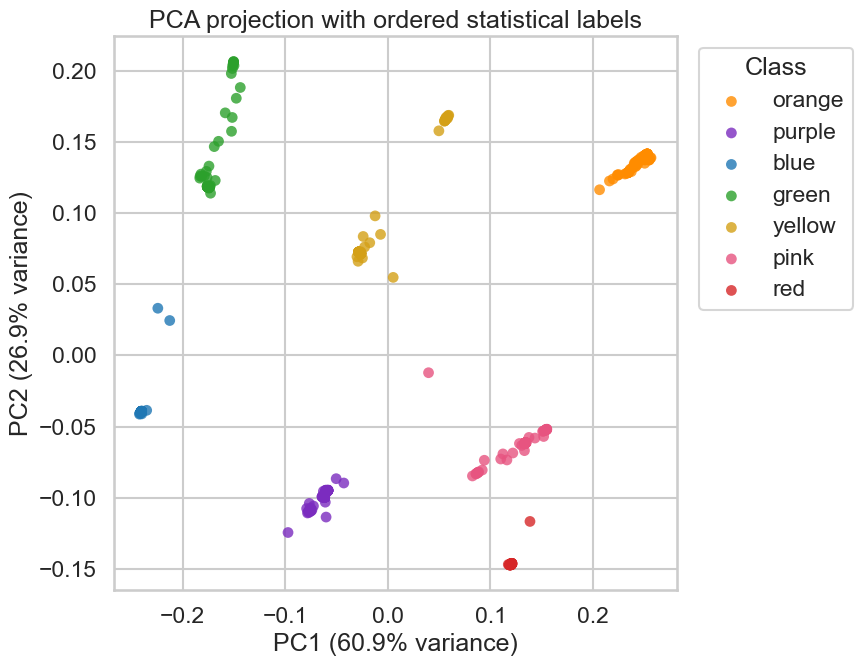

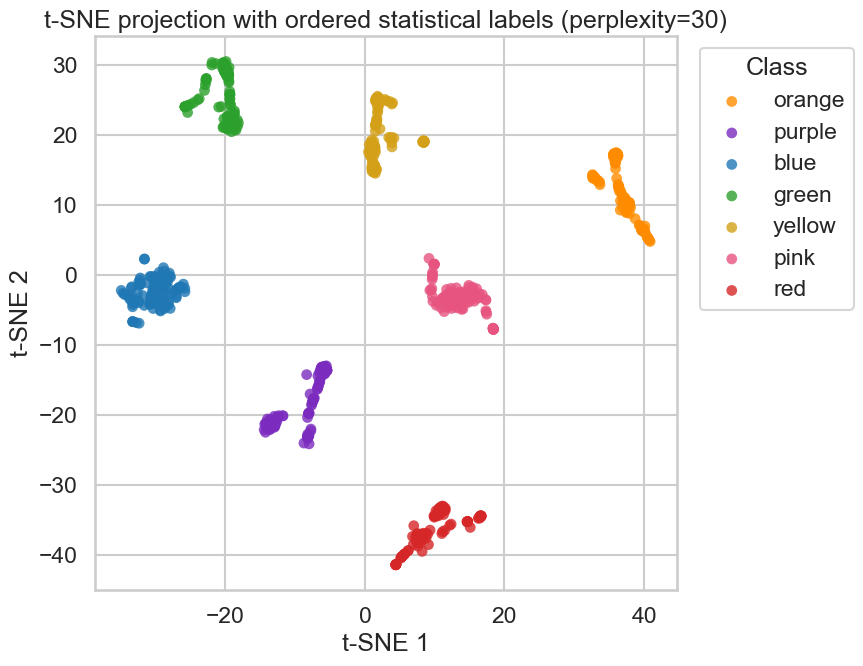

In [31]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_norm)
plot_projection(
    X_pca,
    class_names,
    "PCA projection with ordered statistical labels",
    f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
    f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)",
)

tsne_perplexity = min(30, max(5, len(X_norm) // 20))
tsne = TSNE(
    n_components=2,
    perplexity=tsne_perplexity,
    init="pca",
    learning_rate="auto",
    random_state=RANDOM_STATE,
)
X_tsne = tsne.fit_transform(X_norm)
plot_projection(
    X_tsne,
    class_names,
    f"t-SNE projection with ordered statistical labels (perplexity={tsne_perplexity})",
    "t-SNE 1",
    "t-SNE 2",
)

## 4. Compare Sample Similarity

The heatmap highlights which samples are closest after sorting by the inferred named classes. The histogram compares cosine similarity within a class versus across different classes under the ordered segmentation.

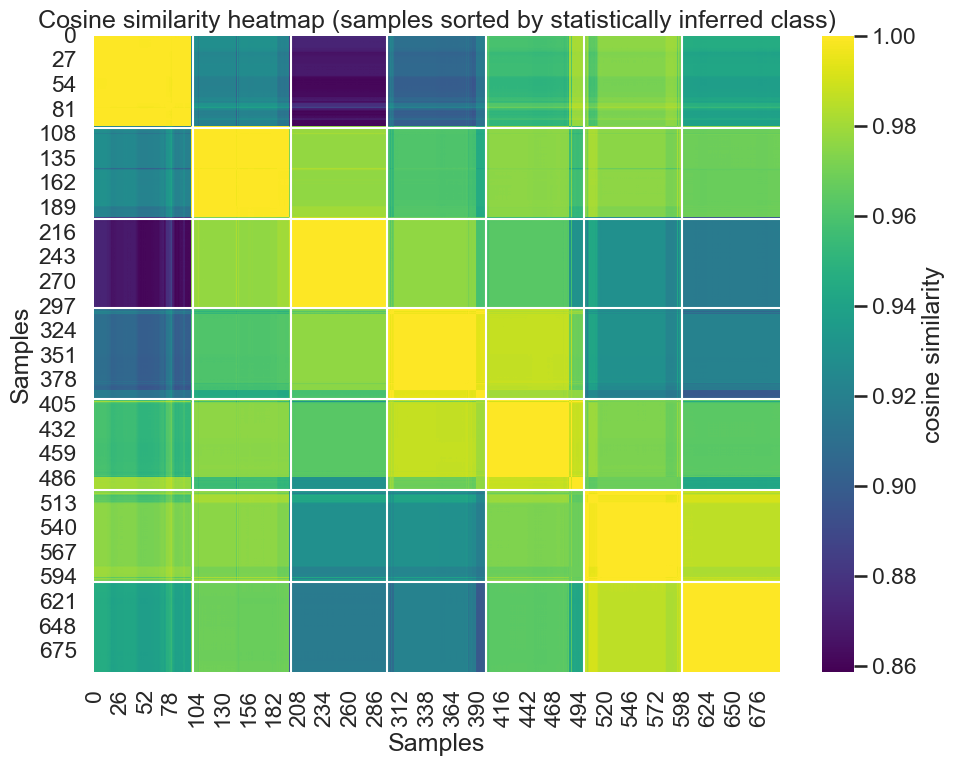

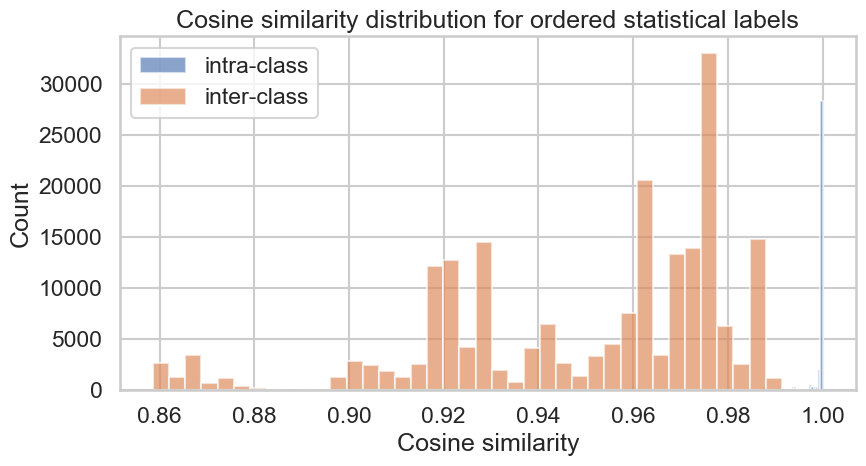

In [32]:
sorted_index = np.argsort(class_ids)
sorted_class_names = class_names[sorted_index]
sim_matrix = cosine_similarity(X_norm[sorted_index])

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, cmap="viridis", cbar_kws={"label": "cosine similarity"})
_, counts = np.unique(sorted_class_names, return_counts=True)
for boundary in np.cumsum(counts)[:-1]:
    plt.axhline(boundary, color="white", linewidth=1.5)
    plt.axvline(boundary, color="white", linewidth=1.5)
plt.title("Cosine similarity heatmap (samples sorted by statistically inferred class)")
plt.xlabel("Samples")
plt.ylabel("Samples")
plt.tight_layout()
plt.show()

intra = []
inter = []
for i in range(len(X_norm) - 1):
    similarities = X_norm[i + 1 :] @ X_norm[i]
    same_class = class_ids[i + 1 :] == class_ids[i]
    intra.extend(similarities[same_class].tolist())
    inter.extend(similarities[~same_class].tolist())

plt.figure(figsize=(9, 5))
plt.hist(intra, bins=40, alpha=0.65, label="intra-class")
plt.hist(inter, bins=40, alpha=0.65, label="inter-class")
plt.legend()
plt.title("Cosine similarity distribution for ordered statistical labels")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 5. Inspect Class Centroids

This section summarizes each inferred named class with its centroid, both in PCA space and across the original 10 normalized sensor features.

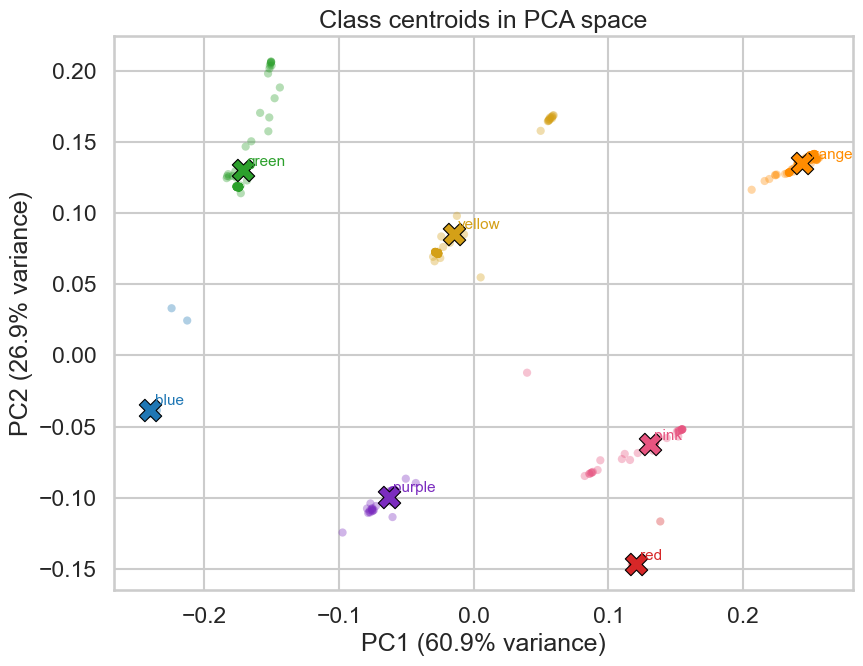

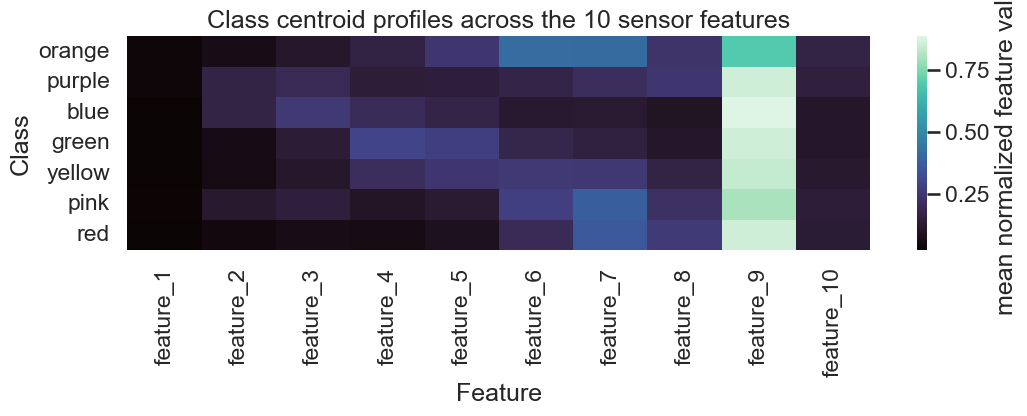

In [33]:
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(9, 7))
for class_index, label in enumerate(class_order):
    members = class_names == label
    plt.scatter(
        X_pca[members, 0],
        X_pca[members, 1],
        s=35,
        alpha=0.35,
        color=CLASS_COLOR_MAP[label],
        edgecolor="none",
    )
    plt.scatter(
        centroids_pca[class_index, 0],
        centroids_pca[class_index, 1],
        marker="X",
        s=260,
        color=CLASS_COLOR_MAP[label],
        edgecolor="black",
        linewidth=0.8,
    )
    plt.text(
        centroids_pca[class_index, 0] + 0.003,
        centroids_pca[class_index, 1] + 0.003,
        label,
        fontsize=11,
        color=CLASS_COLOR_MAP[label],
    )

plt.title("Class centroids in PCA space")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4.5))
sns.heatmap(
    centroids,
    cmap="mako",
    xticklabels=FEATURE_NAMES,
    yticklabels=class_order,
    cbar_kws={"label": "mean normalized feature value"},
)
plt.title("Class centroid profiles across the 10 sensor features")
plt.xlabel("Feature")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

## 6. Prepare for a Future Unknown Class

A practical way to prepare for an unknown class is to flag samples that are unusually far from the centroid of their statistically assigned named class.

This does **not** create a true unknown class yet, but it gives you a first low-confidence bucket that a future AI model could treat as `unknown`.

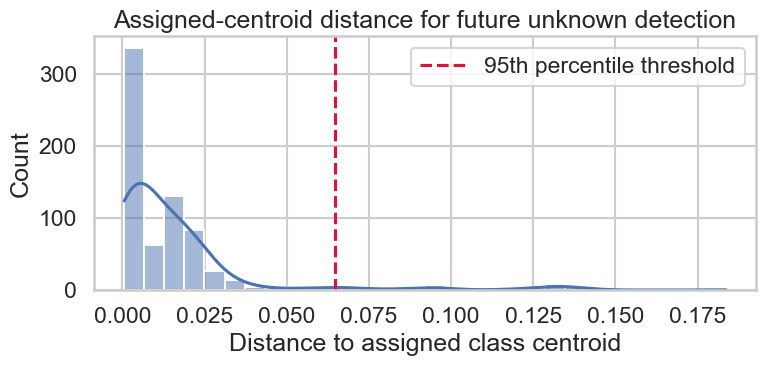

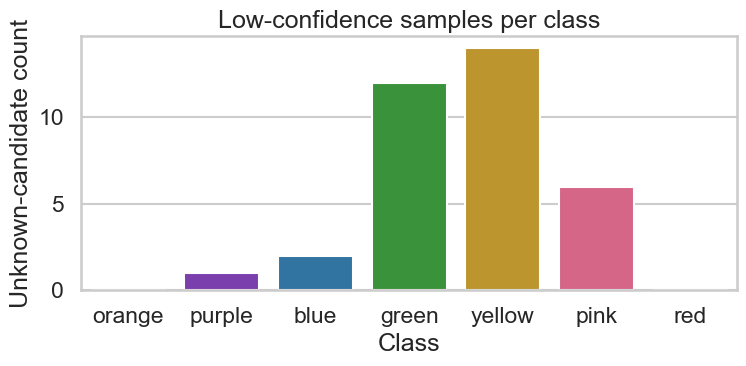

Flagged 35 samples (5.0%) as unknown candidates using the 95th percentile distance threshold.


In [34]:
unknown_counts = [
    int(np.sum(unknown_candidates & (class_names == label)))
    for label in class_order
]

plt.figure(figsize=(8, 4))
sns.histplot(assigned_distances, bins=30, kde=True, color="#4c72b0")
plt.axvline(
    unknown_distance_threshold,
    color="crimson",
    linestyle="--",
    label=f"{UNKNOWN_DISTANCE_PERCENTILE}th percentile threshold",
)
plt.title("Assigned-centroid distance for future unknown detection")
plt.xlabel("Distance to assigned class centroid")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x=class_order, y=unknown_counts, hue=class_order, palette=CLASS_COLOR_MAP, legend=False)
plt.title("Low-confidence samples per class")
plt.xlabel("Class")
plt.ylabel("Unknown-candidate count")
plt.tight_layout()
plt.show()

print(
    f"Flagged {int(np.sum(unknown_candidates))} samples "
    f"({np.mean(unknown_candidates):.1%}) as unknown candidates using the "
    f"{UNKNOWN_DISTANCE_PERCENTILE}th percentile distance threshold."
)